<a href="https://colab.research.google.com/github/BrunoLuce/7_Days_of_Code_Alura-Python-Pandas/blob/main/BRapic_ODS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importando Bibliotecas
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np


In [ ]:
#Importando Biblioteca para ler a tabela
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [ ]:
#Importando tabela do Google
spreadsheet = gc.open ('Trabalhos Brapci')


In [ ]:
#criando um leitor de aba da tabela e um Data Frame para utilizar os dados
# Ler dados de diferentes abas
sheet1 = spreadsheet.get_worksheet(0)  # Primeira aba
sheet2 = spreadsheet.get_worksheet(1)  # Segunda aba
sheet3 = spreadsheet.get_worksheet(2) # terceira aba

In [ ]:
import re
import pandas as pd

# 1) Normalizar header (tira espaços extras, padroniza maiúsculas/minúsculas se quiser)
def normalize_header(h):
    if h is None:
        return ""
    # remove espaços nas bordas e substitui múltiplos espaços internos por 1
    h = re.sub(r"\s+", " ", str(h).strip())
    return h

# 2) Tornar headers únicos e criar nomes para vazios
def make_unique_headers(headers):
    seen = {}
    unique_headers = []
    for i, header in enumerate(headers):
        h = header or f"Coluna_{i+1}"  # se vier vazio, nomeia automaticamente
        if h in seen:
            seen[h] += 1
            unique_headers.append(f"{h}_{seen[h]}")  # ex.: "Brasil", "Brasil_1", "Brasil_2"
        else:
            seen[h] = 0
            unique_headers.append(h)
    return unique_headers

# 3) Ler worksheet -> DataFrame sem get_all_records
def worksheet_to_df(ws):
    values = ws.get_all_values()
    if not values:
        return pd.DataFrame()
    # primeira linha: headers
    raw_headers = [normalize_header(h) for h in values[0]]
    headers = make_unique_headers(raw_headers)

    # demais linhas: dados
    rows = values[1:]

    # padroniza o comprimento de cada linha para bater com o número de colunas
    n_cols = len(headers)
    rows = [row + [""] * (n_cols - len(row)) if len(row) < n_cols else row[:n_cols] for row in rows]

    df = pd.DataFrame(rows, columns=headers)

    # opcional: converter números onde fizer sentido
    # df = df.apply(pd.to_numeric, errors="ignore")

    return df

# Uso:
ODS   = worksheet_to_df(sheet1)
agenda = worksheet_to_df(sheet2)
Total  = worksheet_to_df(sheet3)

In [ ]:
#Testando Base
ODS.info()
ODS.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 10 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

,Paulo Marchiori Buss: José Roberto Ferreira; Claudia Hoirisch; Álvaro H. Matida,RECIIS – R. Eletr. de Com. Inf,Coluna_3,2012,Brasil,Brasil_1,Desenvolvimento sustentável e governança global em saúde– Da Rio+20 aos Objetivos de Desenvolvimento Sustentável(ODS) pós-2015,"Rio + 20; Desenvolvimento sustentável; Governança global em saúde; ODMpós-2015; Objetivos de Desenvolvimento Sustentável (ODS), Cooperação sul - su","Os autores examinam o documento resultante da Conferência das Nações Unidas sobreDesenvolvimento Sustentável (CNUDS), conhecida como Rio+20, realizada em junho de 2012analisando o papel da economia verde no processo de desenvolvimento e na erradicação dapobreza, bem como os requisitos para uma governança equilibrada das dimensões ambiental,econômica e social. O documento final da CNUDS, intitulado ‘O Futuro que Queremos’, defendeum sistema multilateral inclusivo e propõe o estabelecimento de um fórum politicointergovernamental de alto nível, a partir da Comissão sobre Desenvolvimento Sustentável(CDS), assim como o fortalecimento do Programa das Nações Unidas para o Meio Ambiente(PNUMA), realçando a necessidade de ampla participação dos programas, fundos e agênciasdas Nações Unidas, incluindo as instituições financeiras internacionais. Reconhece a saúdecomo pré-condição e resultado para as três dimensões do desenvolvimento sustentável edestaca a importância de estabelecer objetivos coerentes e integrados à Agenda deDesenvolvimento das Nações Unidas pós-2015, além dos três ODM diretamente relacionadas àsaúde. Os Estados Membros insistiram no cumprimento dos compromissos relacionados àAjuda Oficial ao Desenvolvimento (AOD), incluindo a dedicação de 0,7% do PIB de paísesdesenvolvidos para apoiar os países em desenvolvimento e enfatizaram a possibilidade deobtenção de recursos adicionais através da cooperação sul-sul e da cooperação triangular, como expressão de solidariedade entre os países e, destacaram a importância dasflexibilidades do Acordo TRIPS para um melhor aproveitamento das tecnologias necessárias aodesenvolvimento. Finalmente, aprovaram o estabelecimento de um Grupo de Trabalho (GT)para elaborar proposta para os Objetivos de Desenvolvimento Sustentável (ODS) a seremincorporados à agenda de desenvolvimento pós-2015, o que deverá contar com o apoiotécnico de todas as Agências das Nações Unidas (BM, FMI, OMC, incluindo agências sociaiscomo OMS, entre outras). O resultado desse esforço será apresentado à Assembleia Geral dasNações Unidas (AGNU) em 2013, a tempo de poder influenciar a formulação dos ODM pós-2015, especialmente para melhorar a saúde humana.",https://www.reciis.icict.fiocruz.br/index.php/reciis/article/view/759
0,Fernanda Xavier Guimarães;\r\nMaria Isabel de ...,"Páginas A&B, Arquivos e Bibliotecas",,2016,Brasil,Portugal,A BIBLIOTECA ESCOLAR E A FORMAÇÃO DO BIBLIOTEC...,: Biblioteca escolar no Brasil; Formação do bi...,: O estudo objetivou analisar as matrizes curr...,https://brapci.inf.br/#/v/69980
1,Marli Dias de Souza Pinto\nGenilson Geraldo\nS...,,"Congresso de Gestão Estratégica da Informação,...",2017,Brasil,Brasil,O desafio da inclusão por meio da biblioteca u...,Ciência da informação;\nBiblioteca universitár...,A biblioteca tem que contribuir com os Objetiv...,https://brapci.inf.br/#/v/147521
2,Helouise Hellen de Godoi Viola\nMarli Dias de ...,,Seminário Nacional de Gestão da Informação e d...,2017,Brasil,Brasil,PROPOSTA DE GESTÃO DE PROJETOS E OS OBJETIVOS ...,Ciência da informação; Gestão de projeto; Agen...,A ONU desenvolveu a Agenda 2030 estruturada em...,https://brapci.inf.br/#/v/147346
3,Marli Dias de Souza Pinto\nGenilson Geraldo\nS...,,Seminário Nacional de Gestão da Informação e d...,2017,Brasil,Brasil,O desafio da inclusão por meio da biblioteca u...,Ciência da informação;\nBiblioteca universitár...,A biblioteca tem que contribuir com os Objetiv...,https://brapci.inf.br/#/v/147231
4,Rosa Emma Monfasani,Revista Brasileira de Biblioteconomia e Docume...,,2017,Argentina,Brasil,Las b

In [ ]:
agenda.shape

(100, 10)

In [ ]:
#visualizando o total da planilha

Total.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Autores             188 non-null    object
 1   Revista             188 non-null    object
 2   Evento              188 non-null    object
 3   Ano                 188 non-null    object
 4   País do trabalho    188 non-null    object
 5   País da Publicação  188 non-null    object
 6   Título              188 non-null    object
 7   Palavras-Chave      188 non-null    object
 8   Resumo              188 non-null    object
 9   Link                188 non-null    object
dtypes: object(10)
memory usage: 14.8+ KB


In [ ]:
Total.shape



(188, 10)

In [ ]:
Total['Evento'].shape

(188,)

In [ ]:
Total.groupby('Evento').sum()


,Autores,Revista,Ano,País do trabalho,País da Publicação,Título,Palavras-Chave,Resumo,Link
Evento,,,,,,,,,
,Paulo Marchiori Buss: José Roberto Ferreira; C...,"RECIIS – R. Eletr. de Com. InfPáginas A&B, Arq...",2012201620172017201720172017201720172017201820...,BrasilBrasilBrasilBrasilBrasilBrasilBrasilArge...,BrasilPortugal BrasilBrasilBrasilBrasilBrasilB...,Desenvolvimento sustentável e governança globa...,Rio + 20; Desenvolvimento sustentável; Governa...,Os autores examinam o documento resu...,https://www.reciis.icict.fiocruz.br/index.php/...
12º Conferência Luso-brasileira de Ciência Aberta,Hellinton Staevie dos Santos;\nManuella Marinh...,,2021,Brasil,Portugal,Acesso Aberto no Extremo Norte do Brasil: prom...,,,https://brapci.inf.br/#/v/252952
CBBD,Daniela Fernanda Assis de Oliveira Spudeit;\nJ...,Revista Brasileira de Biblioteconomia e Docume...,2017201720172017,BrasilBrasilBrasilBrasil,BrasilBrasilBrasilBrasil,BIBLIOTECAS PARQUE E AGENDA 2030:\nanálise das...,Biblioteca pública. Biblioteca parque.\nSusten...,O presente trabalho teve como objetivo analisa...,https://brapci.inf.br/#/v/2064https://brapci.i...
"Congresso de Gestão Estratégica da Informação, Empreendedorismo e Inovação",Marli Dias de Souza Pinto\nGenilson Geraldo\nS...,,20172019,BrasilBrasil,BrasilBrasil,O desafio da inclusão por meio da biblioteca u...,Ciência da informação;\nBiblioteca universitár...,A biblioteca tem que contribuir com os Objetiv...,https://brapci.inf.br/#/v/147521https://brapci...
ENANCIB,Everton da Silva Camillo;\nClaudio Marcondes d...,,20192021,BrasilBrasil,BrasilBrasil,ADERÊNCIAS ENTRE O ODS 4 E POLÍTICAS PÚBLICAS ...,Políticas públicas; Leitura; Desenvolvimento S...,O artigo apresenta resultados de um estudo que...,https://brapci.inf.br/#/v/123375https://ancib....
Enacib,Danielle Pinho Silva; Genilson Geraldo; Marli ...,,2021,Brasil,Brasil,BIBLIOTECAS COMUNITÁRIAS SOB A PERSPECTIVA DA ...,biblioteca comunitária; socialização do conhec...,A Biblioteca comunitária se insere como espaço...,https://enancib.ancib.org/index.php/enancib/xx...
Enancb,Jaqueline Silva de Souza; José Carlos Sales do...,,2023,Brasil,Brasil,DESIGUALDADE DIGITAL DE GÊNERO EM ABRAGÊNCIA I...,desigualdade digital gênero; igualdade gênero;...,Esta investigação resgata a problemática da De...,https://brapci.inf.br/#/v/257721
Enancbi,Tatiana Rossi\nAna Camila Nobre Xavier Nunes\n...,,2023,Brasil,Brasil,SERVIÇOS PRESTADOS POR BIBLIOTECAS UNIVERSITÁR...,estudantes estrangeiros; serviços de bibliotec...,A crescente internacionalização do ensino supe...,
Enancib,Victor Ferreira\nJúlia Tereza Abrão Vieira Lou...,,2017202120212021202120212021202120212022202220...,BrasilBrasilBRasilBrasilBrasilBrasilBrasilBRas...,BrasilBrasilBrasilBrasilBrasilBrasilBrasilBras...,ANÁLISE BIBLIOMÉTRICA NA ÁREA DE PESQUISA EM C...,Bibliometria; Regressão não linear; Cidades in...,A produção científica de diversas áreas do con...,https://brapci.inf.br/#/v/104570https://enanci...


In [ ]:
# Definir os termos que você deseja padronizar e seus correspondentes
termos_padrao = {'Enancbi': 'Enancib', 'ENANCIB': 'Enancib', 'Enacib': 'Enancib', 'Enancb':'Enancib',}

# Padronizar os termos na coluna

Total['Evento'] = Total['Evento'].replace(termos_padrao, regex=True)


In [ ]:
Total.groupby('Evento').sum()

,Autores,Revista,Ano,País do trabalho,País da Publicação,Título,Palavras-Chave,Resumo,Link
Evento,,,,,,,,,
,Paulo Marchiori Buss: José Roberto Ferreira; C...,"RECIIS – R. Eletr. de Com. InfPáginas A&B, Arq...",2012201620172017201720172017201720172017201820...,BrasilBrasilBrasilBrasilBrasilBrasilBrasilArge...,BrasilPortugal BrasilBrasilBrasilBrasilBrasilB...,Desenvolvimento sustentável e governança globa...,Rio + 20; Desenvolvimento sustentável; Governa...,Os autores examinam o documento resu...,https://www.reciis.icict.fiocruz.br/index.php/...
12º Conferência Luso-brasileira de Ciência Aberta,Hellinton Staevie dos Santos;\nManuella Marinh...,,2021,Brasil,Portugal,Acesso Aberto no Extremo Norte do Brasil: prom...,,,https://brapci.inf.br/#/v/252952
CBBD,Daniela Fernanda Assis de Oliveira Spudeit;\nJ...,Revista Brasileira de Biblioteconomia e Docume...,2017201720172017,BrasilBrasilBrasilBrasil,BrasilBrasilBrasilBrasil,BIBLIOTECAS PARQUE E AGENDA 2030:\nanálise das...,Biblioteca pública. Biblioteca parque.\nSusten...,O presente trabalho teve como objetivo analisa...,https://brapci.inf.br/#/v/2064https://brapci.i...
"Congresso de Gestão Estratégica da Informação, Empreendedorismo e Inovação",Marli Dias de Souza Pinto\nGenilson Geraldo\nS...,,20172019,BrasilBrasil,BrasilBrasil,O desafio da inclusão por meio da biblioteca u...,Ciência da informação;\nBiblioteca universitár...,A biblioteca tem que contribuir com os Objetiv...,https://brapci.inf.br/#/v/147521https://brapci...
Enancib,Danielle Pinho Silva; Genilson Geraldo; Marli ...,,2021202320232017201920212021202120212021202120...,BrasilBrasilBrasilBrasilBrasilBrasilBRasilBras...,BrasilBrasilBrasilBrasilBrasilBrasilBrasilBras...,BIBLIOTECAS COMUNITÁRIAS SOB A PERSPECTIVA DA ...,biblioteca comunitária; socialização do conhec...,A Biblioteca comunitária se insere como espaço...,https://enancib.ancib.org/index.php/enancib/xx...
Enancib,Everton da Silva Camillo ; Claudio Marcondes ...,,2021,Brasil,BRasil,DISSONÂNCIAS ENTRE O PNLL E O ODS 4 DA AGENDA ...,política pública; promoção da leitura; desenvo...,: A pesquisa parte do pressuposto de que o Pla...,https://brapci.inf.br/#/v/258562
Widat 2023,Genilson Geraldo; Priscila Machado Borges Sena...,,2023,BRasil,Brasil,Informação para o monitoramento dos objetivos ...,Agenda 2030; Ciência cidadã;Ciência da informa...,Introdução: a ciência cidadã possui potenciali...,https://brapci.inf.br/#/v/227422


In [ ]:
Total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Autores             188 non-null    object
 1   Revista             188 non-null    object
 2   Evento              188 non-null    object
 3   Ano                 188 non-null    object
 4   País do trabalho    188 non-null    object
 5   País da Publicação  188 non-null    object
 6   Título              188 non-null    object
 7   Palavras-Chave      188 non-null    object
 8   Resumo              188 non-null    object
 9   Link                188 non-null    object
dtypes: object(10)
memory usage: 14.8+ KB


In [ ]:
#transformando Ano ( que estava como objeto) para datetime
Total['Ano'] = pd.to_datetime(Total['Ano'], format='%Y')
Total['Ano'].head()

,Ano
0,2021-01-01
1,2017-01-01
2,2017-01-01
3,2017-01-01
4,2017-01-01


In [ ]:
#verificando se foi transformado
Total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Autores             188 non-null    object        
 1   Revista             188 non-null    object        
 2   Evento              188 non-null    object        
 3   Ano                 188 non-null    datetime64[ns]
 4   País do trabalho    188 non-null    object        
 5   País da Publicação  188 non-null    object        
 6   Título              188 non-null    object        
 7   Palavras-Chave      188 non-null    object        
 8   Resumo              188 non-null    object        
 9   Link                188 non-null    object        
dtypes: datetime64[ns](1), object(9)
memory usage: 14.8+ KB


In [ ]:
# Preencher células vazias com um valor específico, por exemplo, 'N/A'
valor_preenchimento = 'N/A'
Total.fillna(valor_preenchimento, inplace=True)
Total.to_csv("Trabalhos Brapci.csv", index=False)
print("Células vazias preenchidas com sucesso com '{}'.".format(valor_preenchimento))




Células vazias preenchidas com sucesso com 'N/A'.


In [ ]:
celulas_vazias = ODS.isnull()
celulas_vazias

,Paulo Marchiori Buss: José Roberto Ferreira; Claudia Hoirisch; Álvaro H. Matida,RECIIS – R. Eletr. de Com. Inf,Coluna_3,2012,Brasil,Brasil_1,Desenvolvimento sustentável e governança global em saúde– Da Rio+20 aos Objetivos de Desenvolvimento Sustentável(ODS) pós-2015,"Rio + 20; Desenvolvimento sustentável; Governança global em saúde; ODMpós-2015; Objetivos de Desenvolvimento Sustentável (ODS), Cooperação sul - su","Os autores examinam o documento resultante da Conferência das Nações Unidas sobreDesenvolvimento Sustentável (CNUDS), conhecida como Rio+20, realizada em junho de 2012analisando o papel da economia verde no processo de desenvolvimento e na erradicação dapobreza, bem como os requisitos para uma governança equilibrada das dimensões ambiental,econômica e social. O documento final da CNUDS, intitulado ‘O Futuro que Queremos’, defendeum sistema multilateral inclusivo e propõe o estabelecimento de um fórum politicointergovernamental de alto nível, a partir da Comissão sobre Desenvolvimento Sustentável(CDS), assim como o fortalecimento do Programa das Nações Unidas para o Meio Ambiente(PNUMA), realçando a necessidade de ampla participação dos programas, fundos e agênciasdas Nações Unidas, incluindo as instituições financeiras internacionais. Reconhece a saúdecomo pré-condição e resultado para as três dimensões do desenvolvimento sustentável edestaca a importância de estabelecer objetivos coerentes e integrados à Agenda deDesenvolvimento das Nações Unidas pós-2015, além dos três ODM diretamente relacionadas àsaúde. Os Estados Membros insistiram no cumprimento dos compromissos relacionados àAjuda Oficial ao Desenvolvimento (AOD), incluindo a dedicação de 0,7% do PIB de paísesdesenvolvidos para apoiar os países em desenvolvimento e enfatizaram a possibilidade deobtenção de recursos adicionais através da cooperação sul-sul e da cooperação triangular, como expressão de solidariedade entre os países e, destacaram a importância dasflexibilidades do Acordo TRIPS para um melhor aproveitamento das tecnologias necessárias aodesenvolvimento. Finalmente, aprovaram o estabelecimento de um Grupo de Trabalho (GT)para elaborar proposta para os Objetivos de Desenvolvimento Sustentável (ODS) a seremincorporados à agenda de desenvolvimento pós-2015, o que deverá contar com o apoiotécnico de todas as Agências das Nações Unidas (BM, FMI, OMC, incluindo agências sociaiscomo OMS, entre outras). O resultado desse esforço será apresentado à Assembleia Geral dasNações Unidas (AGNU) em 2013, a tempo de poder influenciar a formulação dos ODM pós-2015, especialmente para melhorar a saúde humana.",https://www.reciis.icict.fiocruz.br/index.php/reciis/article/view/759
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
90,False,False,False,False,False,False,False,False,False,False
91,False,False,False,False,False,False,False,False,False,False
92,False,False,False,False,False,False,False,False,False,False
93,False,False,False,False,False,False,False,False,False,False


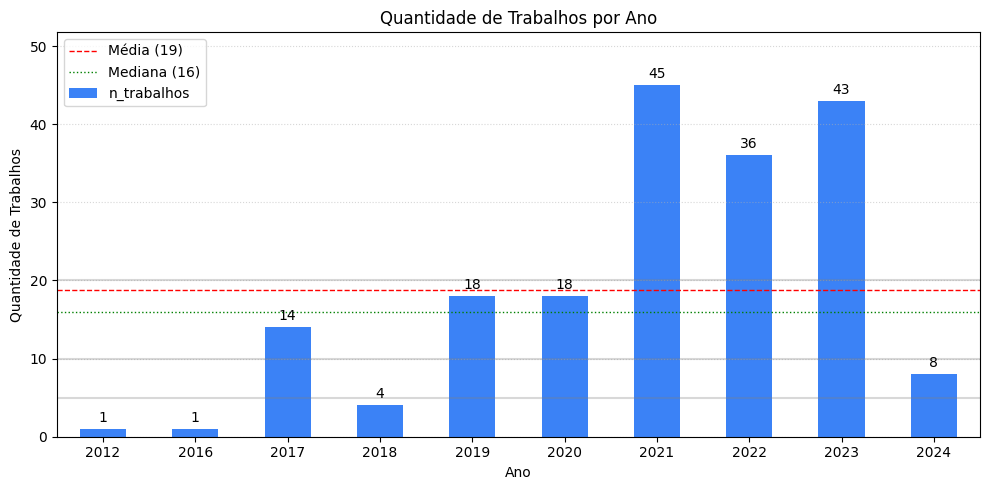

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Agrega: trabalhos por Ano
serie = (
    Total.assign(Ano=pd.to_datetime(Total['Ano'], errors='coerce').dt.year)
         .groupby('Ano').size()
         .rename('n_trabalhos')
         .sort_index()
)

# 2) Plota barras
ax = serie.plot(
    kind='bar',
    figsize=(10, 5),
    color='#3B82F6',
    xlabel='Ano',
    ylabel='Quantidade de Trabalhos',
    title='Quantidade de Trabalhos por Ano',
    rot=0
)

# 3) Números no topo de cada barra
# Matplotlib >= 3.4: bar_label funciona direto
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

# 4) Linhas horizontais de referência
media = float(serie.mean()) if len(serie) else 0.0
mediana = float(serie.median()) if len(serie) else 0.0

ax.axhline(media, color='red', linestyle='--', linewidth=1, label=f'Média ({media:.0f})')
ax.axhline(mediana, color='green', linestyle=':', linewidth=1, label=f'Mediana ({mediana:.0f})')

# Se quiser linhas fixas em valores específicos (ex.: 5, 10, 20):
for y in [5, 10, 20]:
    ax.axhline(y, color='gray', linestyle='-', alpha=0.3)

# 5) Grade horizontal e folga superior
ax.grid(axis='y', linestyle=':', alpha=0.5)
topo = max(1, serie.max() * 1.15)  # 15% de folga
ax.set_ylim(0, topo)

ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd
from matplotlib import colors as mcolors

# Reproduz a ordem de níveis (hue) que o Seaborn usa internamente
event_counts = (
    Total.assign(Ano=pd.to_datetime(Total['Ano'], errors='coerce').dt.year)
         .dropna(subset=['Ano'])
         .groupby(['Evento','Ano']).size().reset_index(name='Count')
)

# Ordem de aparição (igual o seaborn usa)
levels = pd.unique(event_counts['Evento'])

# Paleta "tab10" com tamanho igual ao número de níveis
pal = sns.color_palette('tab10', n_colors=len(levels))

# Mapa Evento -> cor (hex)
mapa_evt_cor = {evt: mcolors.to_hex(col) for evt, col in zip(levels, pal)}

# Hex do marrom do tab10
marrom = '#8c564b'

# Quem é o "marrom"?
evento_marrom = [evt for evt, hexcol in mapa_evt_cor.items() if hexcol.lower() == marrom]
print('Evento com a cor marrom:', evento_marrom)

Evento com a cor marrom: ['Enancib ']


In [ ]:
# Supondo que você tem a lista de eventos que quer na legenda:
eventos_legenda = list(cores_evento.keys())  # ou defina manualmente

# Normalização rápida para pegar variações invisíveis (espaços, acentos, caixa)
import unicodedata, re
def normaliza(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    s = s.str.strip()
    s = s.str.replace(r'\s+', ' ', regex=True)  # espaços duplicados
    s = s.str.upper()
    s = s.map(lambda x: unicodedata.normalize('NFKD', x).encode('ascii','ignore').decode('utf-8'))
    return s

Total['_Evento_norm'] = normaliza(Total['Evento'])

# Também normalize a lista da legenda para comparação justa
legenda_norm = normaliza(pd.Series(eventos_legenda)).tolist()

# Quais "eventos" estão no dado mas não estão na legenda?
fantasmas = (Total.loc[~Total['_Evento_norm'].isin(legenda_norm), '_Evento_norm']
                  .value_counts()
                  .head(30))
print('Eventos não presentes na legenda (top 30):\n', fantasmas)

Eventos não presentes na legenda (top 30):
 _Evento_norm
                                                                              151
CONGRESSO DE GESTAO ESTRATEGICA DA INFORMACAO, EMPREENDEDORISMO E INOVACAO      2
12o CONFERENCIA LUSO-BRASILEIRA DE CIENCIA ABERTA                               1
WIDAT 2023                                                                      1
Name: count, dtype: int64


In [ ]:
import pandas as pd

Total['Evento_std'] = (
    Total['Evento'].astype(str)
        .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('utf-8')  # remove acentos
        .str.lower().str.replace(r'[^a-z0-9 ]+', ' ', regex=True)                 # remove pontuação
        .str.replace(r'\s+', ' ', regex=True).str.strip()                         # normaliza espaços
        .map(lambda x: 'ENANCIB' if 'enancib' in x else x.upper())                # mapeia
)

In [ ]:
import numpy as np
import pandas as pd

clean = (
    Total['Evento'].astype(str)
         .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('utf-8')
         .str.lower().str.replace(r'[^a-z0-9 ]+', ' ', regex=True)
         .str.replace(r'\s+', ' ', regex=True).str.strip()
)

anos = clean.str.extract(r'((?:19|20)\d{2})', expand=False)

Total['Evento_std'] = np.where(
    clean.str.contains(r'\benancib\b'),
    np.where(anos.notna(), 'ENANCIB ' + anos, 'ENANCIB'),
    clean.str.upper()
)

In [ ]:
import re
import pandas as pd
from unidecode import unidecode  # pip install unidecode

SINONIMOS = {
    r'\benancib\b': 'ENANCIB',
    r'\bsnbu\b': 'SNBU',
    r'\bcbbd\b': 'CBBD',
    # adicione outros padrões oficiais aqui
}

def padroniza_evento(s, manter_ano_enancib=False):
    if pd.isna(s):
        return pd.NA
    x = unidecode(str(s)).lower()
    x = re.sub(r'[^a-z0-9 ]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()

    # ENANCIB com ano opcional
    if re.search(r'\benancib\b', x):
        if manter_ano_enancib:
            m = re.search(r'(19|20)\d{2}', x)
            if m:
                return f'ENANCIB {m.group(0)}'
        return 'ENANCIB'

    # Demais mapeamentos por padrão
    for patt, can in SINONIMOS.items():
        if re.search(patt, x):
            return can

    return x.upper()

Total['Evento_std'] = Total['Evento'].apply(lambda s: padroniza_evento(s, manter_ano_enancib=True))